# Geographic Visualisation — OD Matrix on the NYC Taxi Zone Map

Renders the 15-min OD tensor (`dataset/output/od_15min_tensor.npz`) on the
TLC Taxi Zone map. Logic lives in `src/geovis/`; this notebook just drives it.

Two views:

- **Choropleth** — per-zone scalar (outflow / inflow / netflow). Answers *where* demand is.
- **Flow map** — strongest origin→destination arcs. Answers *where* demand goes.

Zones are keyed on TLC `LocationID` 1..263; tensor axis `i` ↔ `LocationID = i+1`.
The two `Unknown` zones (264/265) are absent from both tensor and shapefile.

In [1]:
import sys
from pathlib import Path

# This notebook lives in scripts/; make the project root importable.
ROOT = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from src.geovis import (
    load_tensor, load_zones, find_slot,
    slice_window, outflow, inflow, netflow, top_flows,
    plot_choropleth, plot_flow_map,
)

## 1. Load the OD tensor and the zone geometry

In [2]:
tensor, slots = load_tensor()       # (T, N, N) int32  +  DatetimeIndex
zones = load_zones()                # GeoDataFrame indexed by LocationID

print(f"tensor : {tensor.shape}  ({tensor.dtype})")
print(f"slots  : {len(slots)}  {slots[0]}  ->  {slots[-1]}")
print(f"zones  : {len(zones)}  (CRS {zones.crs.to_epsg()})")

tensor : (64320, 263, 263)  (int32)
slots  : 64320  2023-07-01 00:00:00  ->  2025-04-30 23:45:00
zones  : 263  (CRS 2263)


## 2. Choropleth for a single 15-min slot

`outflow` = row sums (requests originating in a zone); `inflow` = column sums
(requests destined for a zone). Request counts are heavily skewed toward
Manhattan, so a **log colour scale** (`log=True`) keeps outer boroughs readable.

slot 19040  2024-01-15 08:00:00  |  total requests = 4,731


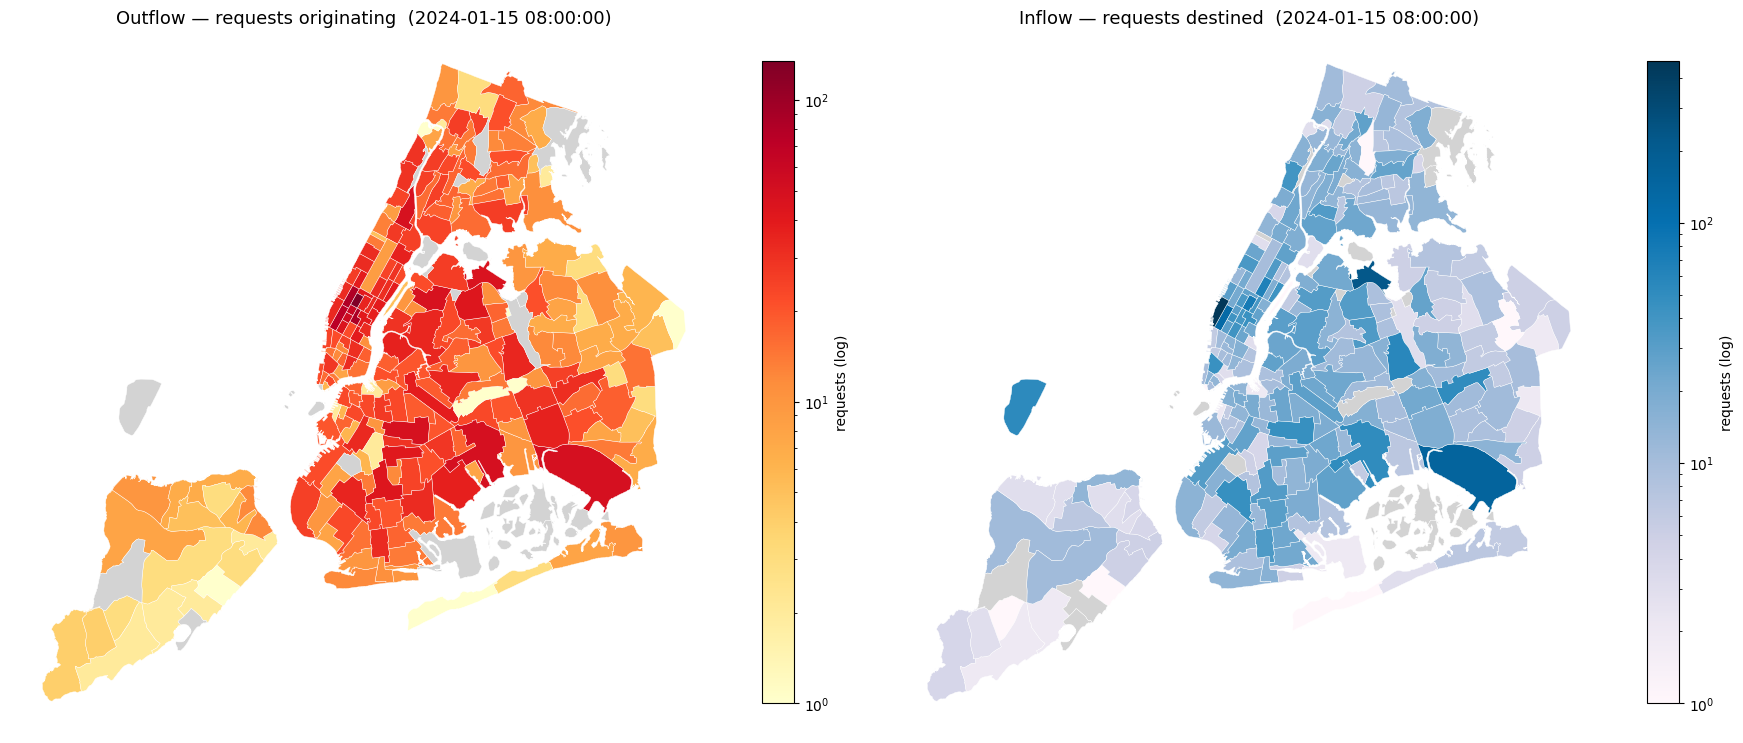

In [3]:
SLOT = "2024-01-15 08:00"          # Mon morning rush
i = find_slot(slots, SLOT)
mat = tensor[i]                     # (N, N) OD matrix for this slot
print(f"slot {i}  {slots[i]}  |  total requests = {mat.sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(18, 11))
plot_choropleth(zones, outflow(mat), ax=axes[0], log=True,
                title=f"Outflow — requests originating  ({slots[i]})",
                legend_label="requests (log)")
plot_choropleth(zones, inflow(mat), ax=axes[1], log=True, cmap="PuBu",
                title=f"Inflow — requests destined  ({slots[i]})",
                legend_label="requests (log)")
plt.tight_layout()
plt.show()

## 3. Net flow — sources vs. sinks

`netflow = inflow - outflow`. Positive (blue) zones pull more trips than they
send (net **sink**); negative (red) zones are net **sources**. A diverging
colormap centred at zero reads best here.

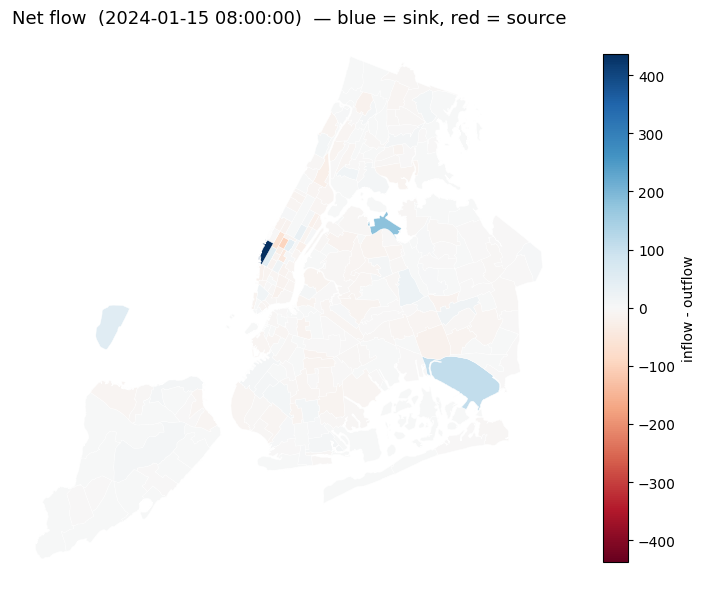

In [4]:
from matplotlib.colors import TwoSlopeNorm

net = netflow(mat)
vmax = float(abs(net).max()) or 1.0

fig, ax = plt.subplots(figsize=(9, 11))
gdf = zones.copy()
gdf["net"] = net                                  # array order == LocationID order
gdf.plot(column="net", ax=ax, cmap="RdBu",
         norm=TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax),
         legend=True, legend_kwds={"label": "inflow - outflow", "shrink": 0.6},
         edgecolor="white", linewidth=0.3)
ax.set_axis_off()
ax.set_title(f"Net flow  ({slots[i]})  — blue = sink, red = source", fontsize=13)
plt.show()

## 4. Aggregate over a time window

A single 15-min slot is noisy. `slice_window` collapses many slots into one
OD matrix — `reduce="sum"` for the window total, `"mean"` for the per-slot
average. Below: the full morning rush 07:00–10:00.

morning-rush total requests = 62,635


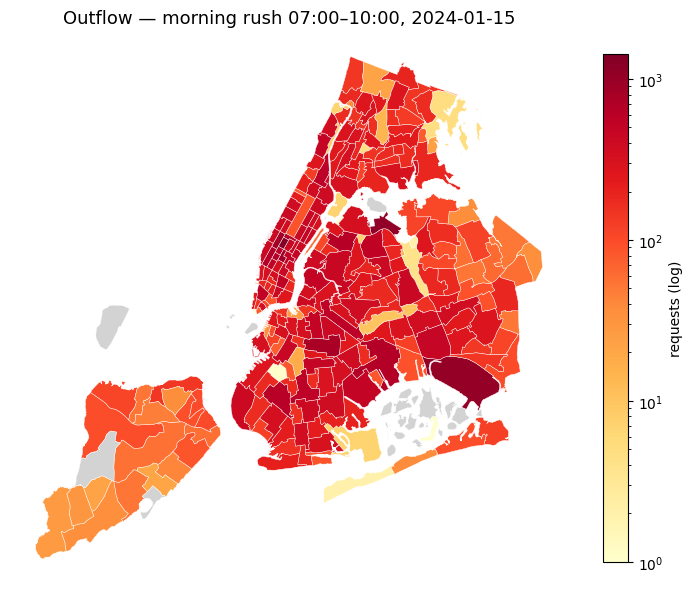

In [5]:
rush = slice_window(tensor, slots,
                    "2024-01-15 07:00", "2024-01-15 10:00", reduce="sum")
print(f"morning-rush total requests = {rush.sum():,}")

plot_choropleth(zones, outflow(rush), log=True,
                title="Outflow — morning rush 07:00–10:00, 2024-01-15",
                legend_label="requests (log)")
plt.show()

## 5. Flow map — strongest OD arcs

A choropleth loses direction. The flow map draws the top-`k` origin→destination
pairs as curved arcs between zone centroids; width and colour scale with the
request count. `k` is capped low on purpose — all 263×263 pairs would be an
unreadable mesh.

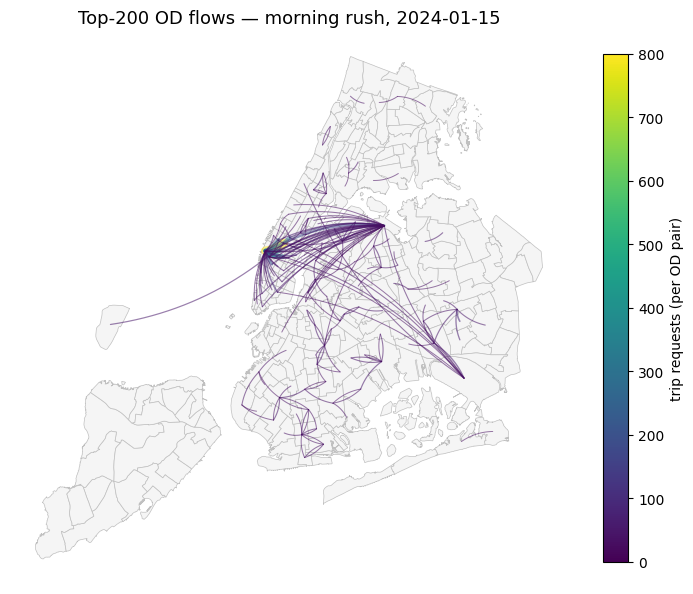

,origin,destination,count
0,Times Sq/Theatre District,West Chelsea/Hudson Yards,800
1,Garment District,West Chelsea/Hudson Yards,397
2,Midtown South,West Chelsea/Hudson Yards,373
3,Clinton East,West Chelsea/Hudson Yards,356
4,Penn Station/Madison Sq West,West Chelsea/Hudson Yards,322
5,Midtown North,West Chelsea/Hudson Yards,284
6,East Chelsea,West Chelsea/Hudson Yards,246
7,Flatiron,West Chelsea/Hudson Yards,209
8,Times Sq/Theatre District,LaGuardia Airport,174
9,Midtown Center,West Chelsea/Hudson Yards,120


In [10]:
plot_flow_map(zones, rush, k=200,
              title="Top-200 OD flows — morning rush, 2024-01-15", 
              basemap_color="#f5f5f5", edgecolor="silver", linewidth=0.5)
plt.show()

# The same ranking as a table:
top_flows(rush, k=10).merge(
    zones[["zone"]], left_on="o_loc", right_index=True
).rename(columns={"zone": "origin"}).merge(
    zones[["zone"]], left_on="d_loc", right_index=True
).rename(columns={"zone": "destination"})[["origin", "destination", "count"]]

## 6. Zoom into the busiest area

On the full-city map the flow mesh over Midtown Manhattan is too dense to
read. `plot_flow_map(zoom="hot")` auto-zooms there: it ranks zones by total
request volume, rejects geographic outliers (e.g. JFK/LaGuardia rank high by
volume but sit far out in Queens) with a median-absolute-deviation test, and
crops the view to the remaining dense core.

The crop is **view-only** — every zone and every top-`k` flow is still drawn;
arcs leaving the zoom box are clipped at its edge, so cross-boundary flows
stay visible.

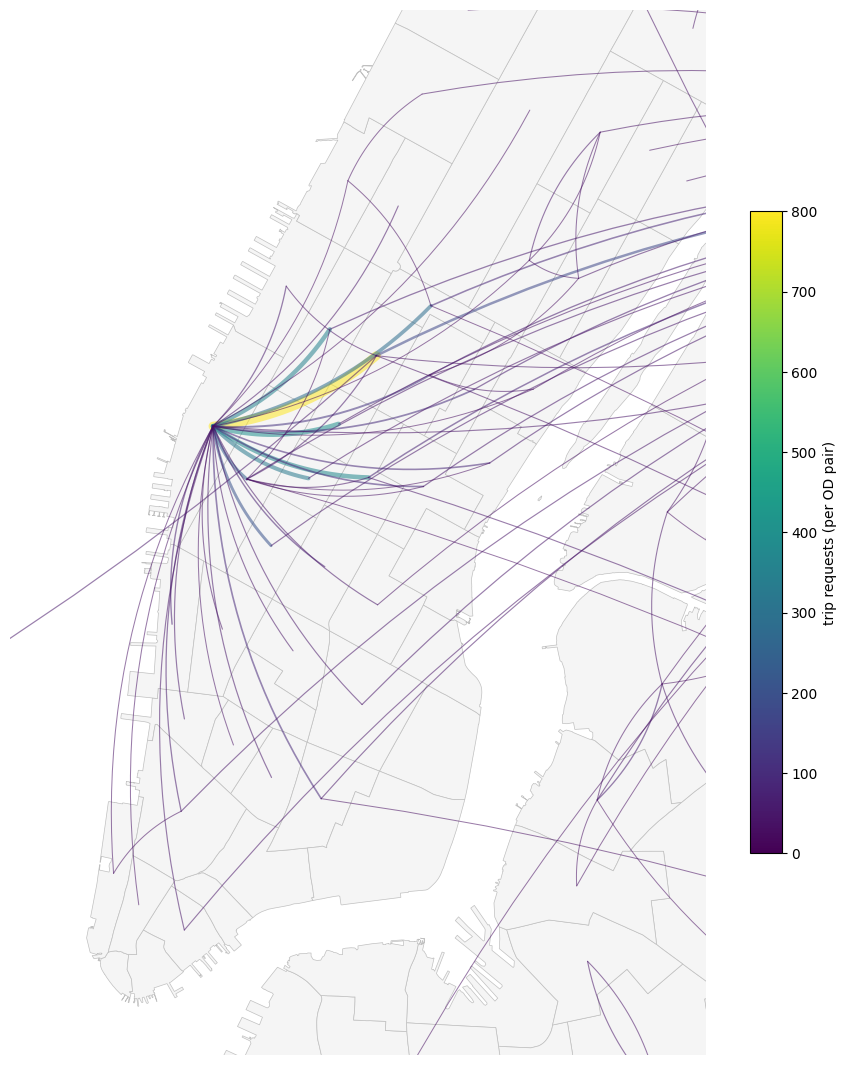

In [12]:
# fig, axes = plt.subplots(1, 2, figsize=(20, 11))
# plot_flow_map(zones, rush, k=200, ax=axes[0],
#               title="Full city")
# plot_flow_map(zones, rush, k=200, ax=axes[1], zoom="hot",
#               title="Hot-zone zoom — all flows kept, clipped at the edge")
plot_flow_map(zones, rush, k=200, zoom="hot",
              basemap_color="#f5f5f5", edgecolor="silver", linewidth=0.5)
plt.tight_layout()
plt.show()

`hot_zones` controls how many top zones define the cluster (bigger = wider
box); `zoom_pad` adds margin. To zoom into a region of your own choosing,
pass an explicit list of `LocationID`s instead of `"hot"`:

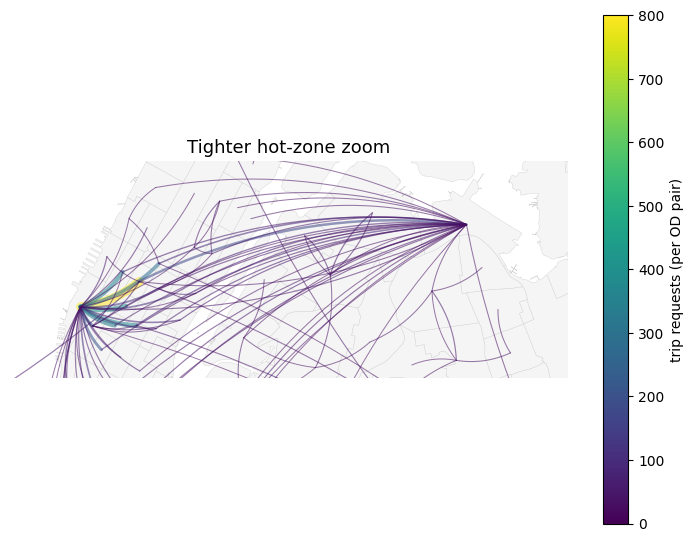

In [8]:
# tighter / looser auto-zoom
plot_flow_map(zones, rush, k=200, zoom="hot", hot_zones=8, zoom_pad=0.1,
              title="Tighter hot-zone zoom")
plt.show()

# manual region — e.g. a hand-picked set of LocationIDs
# plot_flow_map(zones, rush, k=200, zoom=[161, 162, 163, 164, 186, 230],
#               title="Manual region zoom")

## Next steps

- **Interactive map** — for the slide deck, `folium.Choropleth` exports a
  standalone HTML with hover tooltips (`pip install folium`).
- **Animation** — loop `find_slot` over a day and stitch frames into a GIF to
  show demand evolving across slots.
- **Basemap tiles** — `contextily` adds real street context; reproject zones
  to EPSG:3857 first (`pip install contextily`).